# Business Understanding

## Latar Belakang

Penyakit jantung merupakan salah satu penyebab kematian tertinggi di dunia. Menurut berbagai penelitian kesehatan, penyakit kardiovaskular menyebabkan jutaan kematian setiap tahun dan menjadi masalah kesehatan global yang serius.

Deteksi dini terhadap risiko penyakit jantung sangat penting untuk membantu tenaga medis dalam memberikan penanganan yang tepat dan meningkatkan peluang kesembuhan pasien. Namun, proses diagnosis sering kali memerlukan analisis terhadap banyak faktor kesehatan seperti usia, tekanan darah, kadar kolesterol, detak jantung, dan kondisi medis lainnya.

Perkembangan teknologi Artificial Intelligence (AI) dan Machine Learning memungkinkan analisis data kesehatan dilakukan secara lebih cepat dan akurat. Dengan memanfaatkan data pasien yang tersedia, model machine learning dapat digunakan untuk memprediksi kemungkinan seseorang mengalami penyakit jantung berdasarkan karakteristik kesehatannya.

Oleh karena itu, pada proyek ini dilakukan pembangunan model klasifikasi untuk memprediksi penyakit jantung menggunakan dataset Heart Disease Dataset dan membandingkan performa beberapa algoritma machine learning.
## Permasalahan

Berdasarkan latar belakang tersebut, permasalahan yang ingin diselesaikan pada proyek ini adalah:

1. Bagaimana memanfaatkan data kesehatan pasien untuk memprediksi kemungkinan penyakit jantung?
2. Algoritma machine learning apa yang memberikan performa terbaik dalam melakukan klasifikasi penyakit jantung?
3. Faktor-faktor apa yang memiliki hubungan dengan status penyakit jantung berdasarkan analisis data?
## Tujuan Proyek

Tujuan dari proyek ini adalah:

1. Melakukan analisis terhadap dataset penyakit jantung.
2. Membangun model machine learning untuk klasifikasi penyakit jantung.
3. Membandingkan performa beberapa algoritma machine learning.
4. Menentukan model terbaik berdasarkan metrik evaluasi.
5. Membantu proses deteksi dini risiko penyakit jantung melalui pendekatan data-driven.

# Data Understanding

## Sumber Data

Dataset yang digunakan pada penelitian ini adalah **Heart Disease Dataset** yang berisi informasi kesehatan pasien dan status penyakit jantung.

Dataset terdiri dari beberapa atribut kesehatan seperti usia, tekanan darah, kadar kolesterol, detak jantung maksimum, dan faktor medis lainnya yang digunakan untuk memprediksi kemungkinan seseorang mengalami penyakit jantung.

Target klasifikasi pada dataset ini adalah kolom **target**, dengan:

- 0 = Tidak memiliki penyakit jantung
- 1 = Memiliki penyakit jantung

Pada tahap Data Understanding dilakukan analisis awal untuk memahami struktur data, ukuran dataset, tipe data, distribusi target, serta karakteristik masing-masing fitur.

In [1]:
# Import Library

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
# Load Dataset

df = pd.read_csv('Data/heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Menampilkan 5 Data Pertama

Tahap ini dilakukan untuk melihat struktur awal dataset dan memastikan data berhasil dimuat dengan benar.

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Ukuran Dataset

Ukuran dataset diperlukan untuk mengetahui jumlah observasi (baris) dan jumlah fitur (kolom) yang akan digunakan dalam proses analisis dan pemodelan.

In [4]:
print("Jumlah Baris dan Kolom:")
print(df.shape)

Jumlah Baris dan Kolom:
(1025, 14)


In [5]:
print(f"Jumlah Data : {df.shape[0]}")
print(f"Jumlah Kolom : {df.shape[1]}")

Jumlah Data : 1025
Jumlah Kolom : 14


## Informasi Dataset

Tahap ini digunakan untuk melihat tipe data setiap atribut serta mengetahui apakah terdapat nilai kosong (missing value) pada dataset.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## Statistik Deskriptif

Statistik deskriptif digunakan untuk mengetahui karakteristik data seperti:

- Mean
- Median
- Nilai minimum
- Nilai maksimum
- Standar deviasi

Informasi ini membantu memahami distribusi setiap fitur numerik.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## Pemeriksaan Missing Value

Missing value dapat mempengaruhi performa model sehingga perlu diperiksa sebelum dilakukan proses pemodelan.

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
print("Total Missing Value:")
print(df.isnull().sum().sum())

Total Missing Value:
0


## Pemeriksaan Data Duplikat

Data duplikat dapat menyebabkan bias pada proses pelatihan model sehingga perlu diperiksa.

In [10]:
print("Jumlah Data Duplikat:")
print(df.duplicated().sum())

Jumlah Data Duplikat:
723


## Deskripsi Fitur Dataset

Berikut adalah penjelasan masing-masing atribut yang digunakan pada dataset:

In [11]:
feature_description = pd.DataFrame({
    'Fitur': [
        'age',
        'sex',
        'cp',
        'trestbps',
        'chol',
        'fbs',
        'restecg',
        'thalach',
        'exang',
        'oldpeak',
        'slope',
        'ca',
        'thal',
        'target'
    ],

    'Deskripsi': [
        'Usia pasien',
        'Jenis kelamin',
        'Tipe nyeri dada',
        'Tekanan darah saat istirahat',
        'Kadar kolesterol',
        'Gula darah puasa',
        'Hasil elektrokardiogram',
        'Detak jantung maksimum',
        'Angina akibat olahraga',
        'Depresi ST akibat olahraga',
        'Kemiringan segmen ST',
        'Jumlah pembuluh darah utama',
        'Status thalassemia',
        'Status penyakit jantung'
    ]
})

feature_description

,Fitur,Deskripsi
0,age,Usia pasien
1,sex,Jenis kelamin
2,cp,Tipe nyeri dada
3,trestbps,Tekanan darah saat istirahat
4,chol,Kadar kolesterol
5,fbs,Gula darah puasa
6,restecg,Hasil elektrokardiogram
7,thalach,Detak jantung maksimum
8,exang,Angina akibat olahraga
9,oldpeak,Depresi ST akibat olahraga


## Identifikasi Variabel Target

Variabel target yang digunakan pada penelitian ini adalah kolom **target**.

Distribusi target perlu diperiksa untuk mengetahui apakah dataset memiliki kelas yang seimbang atau tidak.

In [12]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [13]:
df['target'].value_counts(normalize=True) * 100

target
1    51.317073
0    48.682927
Name: proportion, dtype: float64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) merupakan tahap untuk memahami karakteristik dataset melalui visualisasi dan analisis statistik. Tahap ini bertujuan untuk mengidentifikasi pola, distribusi data, hubungan antar variabel, serta mendeteksi adanya outlier atau ketidakseimbangan kelas sebelum dilakukan proses pemodelan Machine Learning.

Pada penelitian ini dilakukan beberapa analisis, yaitu:

- Distribusi target
- Distribusi setiap fitur
- Pemeriksaan outlier
- Analisis korelasi antar fitur
- Hubungan beberapa fitur terhadap target

## 1. Distribusi Target

Visualisasi distribusi target bertujuan untuk mengetahui apakah jumlah data pada masing-masing kelas relatif seimbang atau tidak. Dataset yang seimbang akan membantu model Machine Learning menghasilkan performa yang lebih baik.

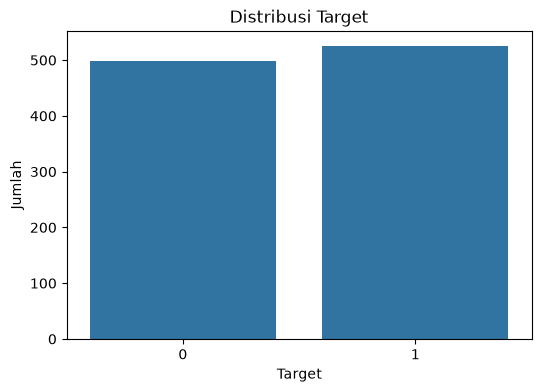

In [56]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='target')

plt.title("Distribusi Target")
plt.xlabel("Target")
plt.ylabel("Jumlah")

plt.savefig('images/distribusi_target.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

In [15]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

### Insight

Berdasarkan grafik distribusi target, jumlah data antara kelas **memiliki penyakit jantung** dan **tidak memiliki penyakit jantung** relatif seimbang sehingga dataset tidak mengalami masalah class imbalance yang signifikan.

## 2. Distribusi Seluruh Fitur

Histogram digunakan untuk melihat penyebaran nilai pada setiap fitur sehingga dapat diketahui karakteristik distribusi masing-masing variabel.

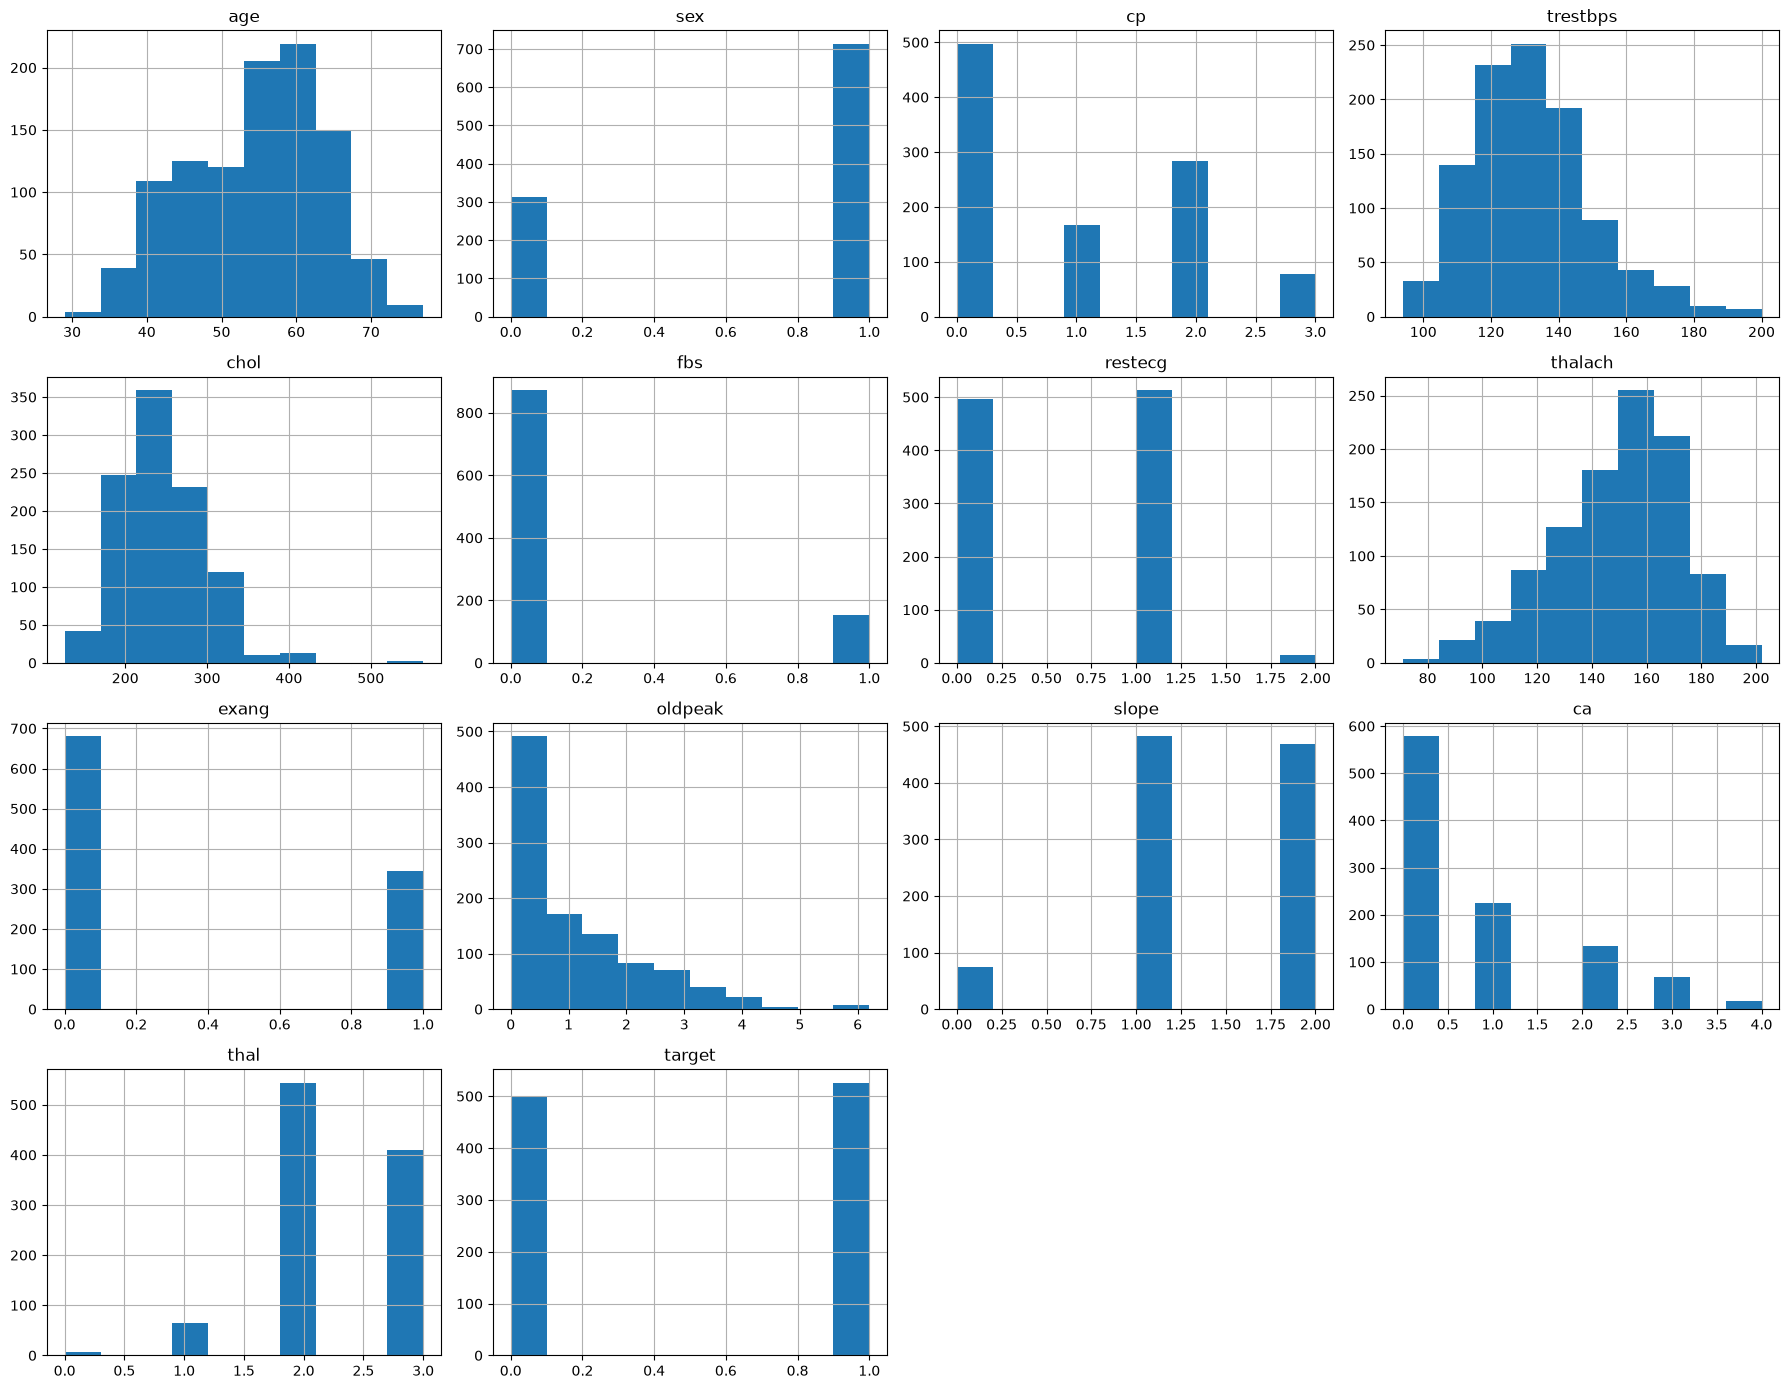

In [57]:
df.hist(figsize=(18,14))

plt.tight_layout()

plt.savefig('images/distribusi_fitur.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Insight

Histogram menunjukkan bahwa setiap fitur memiliki karakteristik distribusi yang berbeda. Beberapa fitur memiliki distribusi normal, sedangkan fitur kategorikal hanya memiliki beberapa nilai unik karena merupakan hasil encoding kategori.

## 3. Pemeriksaan Outlier

Outlier merupakan nilai yang berada jauh dari sebagian besar data lainnya. Pemeriksaan outlier penting karena dapat memengaruhi performa model Machine Learning.

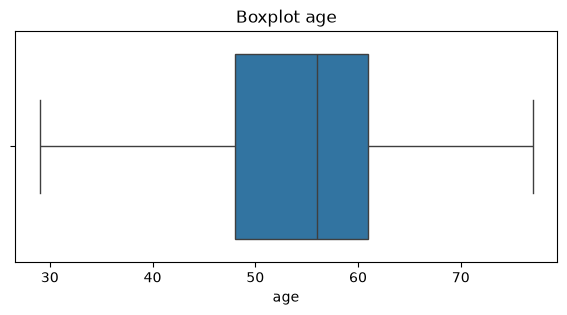

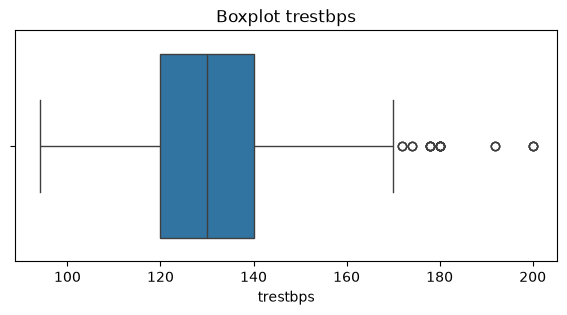

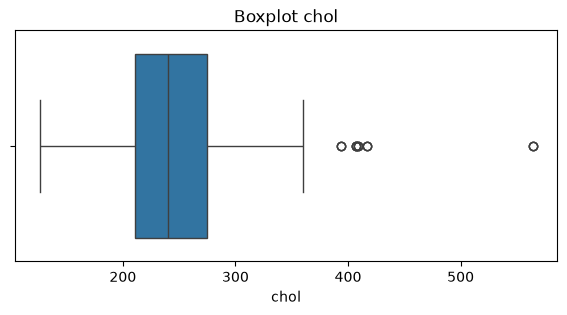

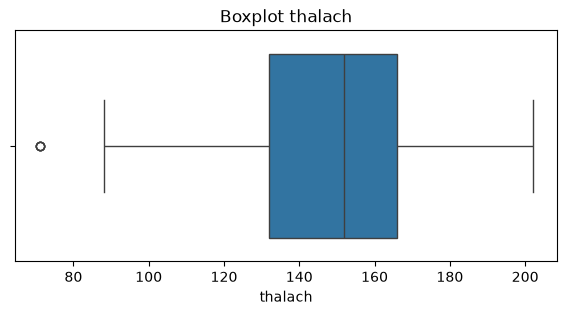

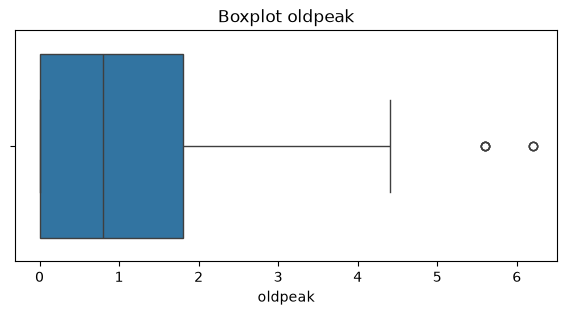

In [58]:
numerical_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

for col in numerical_features:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot {col}')

    plt.savefig(f'images/boxplot_{col}.png',
                dpi=300,
                bbox_inches='tight')

    plt.show()

### Insight

Beberapa fitur seperti **chol**, **trestbps**, dan **oldpeak** memiliki beberapa nilai yang berada di luar rentang interquartile (IQR), sehingga dapat dikategorikan sebagai outlier. Namun, karena data berasal dari kondisi medis pasien, nilai tersebut masih mungkin merepresentasikan kondisi kesehatan yang sebenarnya sehingga tidak langsung dihapus.

## 4. Korelasi Antar Variabel

Heatmap digunakan untuk mengetahui hubungan antar fitur dalam dataset. Nilai korelasi berada pada rentang -1 hingga 1.

Semakin mendekati 1 berarti hubungan positif semakin kuat.

Semakin mendekati -1 berarti hubungan negatif semakin kuat.

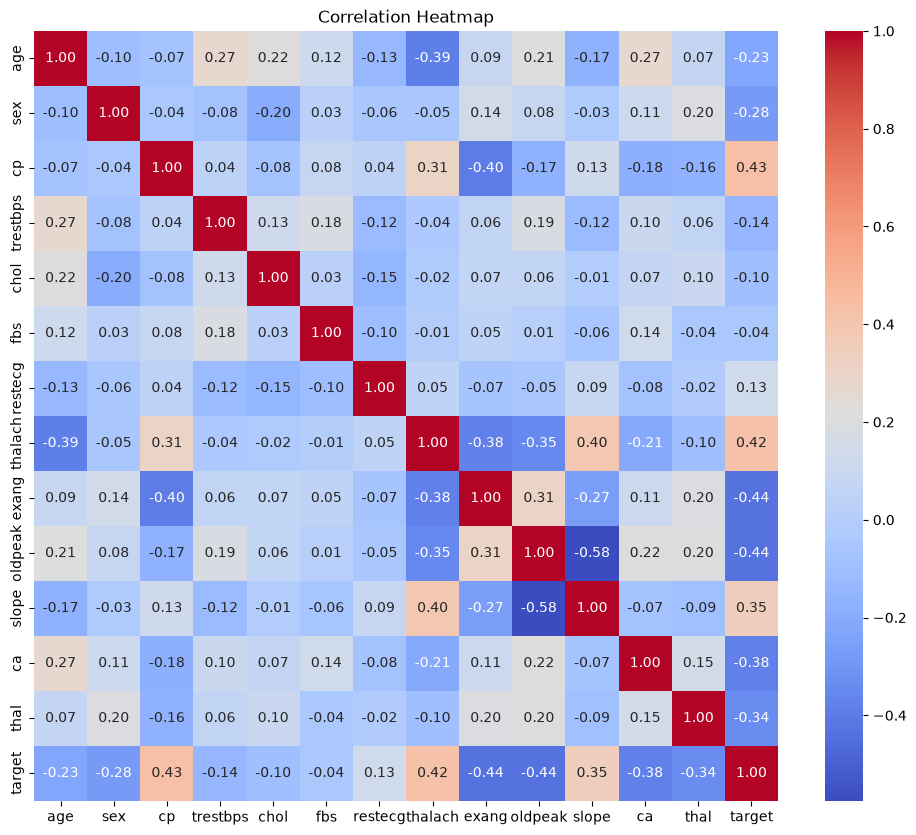

In [59]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.savefig('images/correlation_heatmap.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Insight

Heatmap menunjukkan bahwa beberapa fitur memiliki hubungan yang cukup kuat terhadap variabel target, seperti:

- cp (Chest Pain)
- thalach
- slope
- oldpeak
- exang

Sedangkan beberapa fitur lain memiliki korelasi yang relatif rendah terhadap target.

## 5. Analisis Usia terhadap Penyakit Jantung

Visualisasi ini digunakan untuk melihat hubungan antara usia pasien dengan status penyakit jantung.

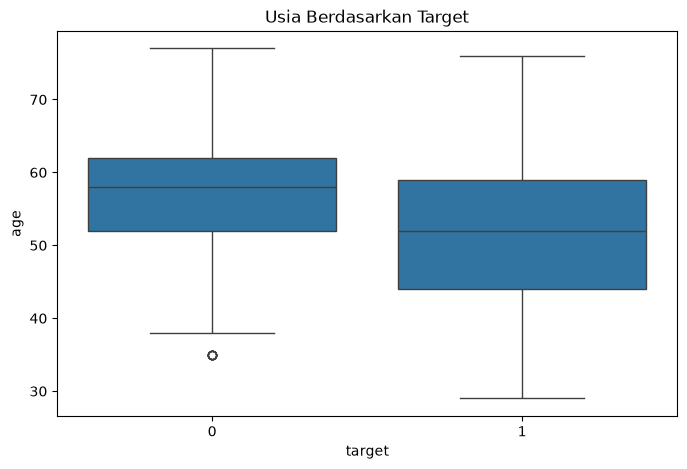

In [60]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='target',
    y='age'
)

plt.title("Usia Berdasarkan Target")

plt.savefig('images/boxplot_usia_target.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Insight

Sebagian besar pasien dengan penyakit jantung berada pada rentang usia dewasa hingga lanjut usia. Hal ini menunjukkan bahwa usia merupakan salah satu faktor yang berpengaruh terhadap risiko penyakit jantung.

## 6. Kadar Kolesterol terhadap Penyakit Jantung

Analisis ini bertujuan untuk mengetahui distribusi kadar kolesterol berdasarkan status penyakit jantung.

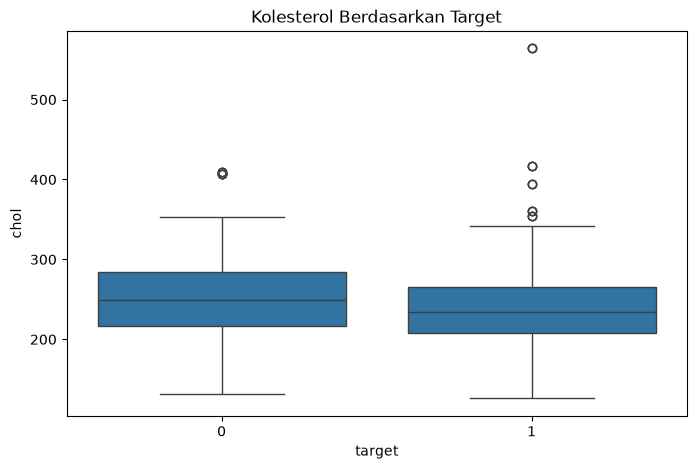

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='target',
    y='chol'
)

plt.title("Kolesterol Berdasarkan Target")

plt.savefig('images/boxplot_kolesterol.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Insight

Nilai kolesterol pada kedua kelompok memiliki rentang yang cukup luas. Beberapa pasien dengan penyakit jantung memiliki kadar kolesterol tinggi, meskipun terdapat pula pasien dengan kadar kolesterol normal. Hal ini menunjukkan bahwa kolesterol bukan satu-satunya faktor yang memengaruhi penyakit jantung.

## 7. Detak Jantung Maksimum

Fitur **thalach** menunjukkan detak jantung maksimum yang dicapai pasien selama pengujian.

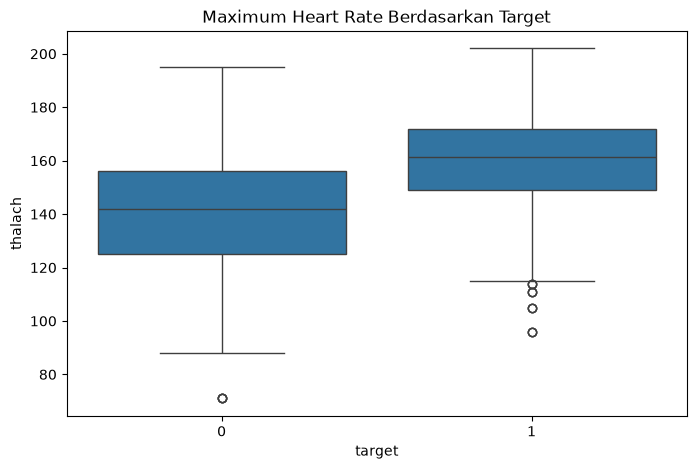

In [62]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='target',
    y='thalach'
)

plt.title("Maximum Heart Rate Berdasarkan Target")

plt.savefig('images/boxplot_max_heart_rate.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Insight

Pasien dengan penyakit jantung cenderung memiliki distribusi nilai detak jantung maksimum yang berbeda dibandingkan pasien tanpa penyakit jantung. Hal ini menunjukkan bahwa fitur **thalach** berpotensi menjadi salah satu prediktor penting dalam proses klasifikasi.

# Kesimpulan Exploratory Data Analysis

Berdasarkan hasil eksplorasi data dapat disimpulkan bahwa:

- Dataset memiliki distribusi target yang relatif seimbang.
- Tidak ditemukan missing value pada dataset.
- Beberapa fitur numerik memiliki outlier, namun masih dianggap valid karena berasal dari data medis.
- Fitur seperti **cp**, **thalach**, **oldpeak**, **exang**, dan **slope** menunjukkan hubungan yang cukup kuat dengan target.
- Hasil EDA memberikan gambaran bahwa dataset sudah cukup baik untuk dilanjutkan ke tahap **Data Preparation** dan **Machine Learning Modeling**.

# Data Preparation

Data Preparation merupakan tahap untuk mempersiapkan data sebelum digunakan dalam proses pelatihan model Machine Learning. Tahapan ini bertujuan agar data memiliki format yang sesuai sehingga model dapat bekerja dengan optimal.

Pada penelitian ini dilakukan beberapa tahapan data preparation, yaitu:

- Pemeriksaan tipe data
- Pemisahan fitur dan target
- Pembagian data menjadi data latih (training) dan data uji (testing)
- Standardisasi fitur menggunakan StandardScaler

Karena seluruh atribut pada dataset telah berbentuk numerik, maka proses encoding tidak diperlukan.

## 1. Pemeriksaan Tipe Data

Sebelum melakukan pemodelan, dilakukan pemeriksaan tipe data pada setiap atribut untuk memastikan seluruh fitur dapat diproses oleh algoritma Machine Learning.

In [22]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

### Insight

Berdasarkan hasil pemeriksaan, seluruh atribut pada dataset telah memiliki tipe data numerik (integer maupun float), sehingga tidak diperlukan proses konversi tipe data maupun encoding kategorikal.

## 2. Pemisahan Feature dan Target

Pada tahap ini dataset dipisahkan menjadi:

- Feature (X) sebagai variabel independen.
- Target (y) sebagai variabel yang akan diprediksi.

In [23]:
X = df.drop('target', axis=1)
y = df['target']

print("Shape Feature :", X.shape)
print("Shape Target  :", y.shape)

Shape Feature : (1025, 13)
Shape Target  : (1025,)


In [24]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [25]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

### Insight

Dataset berhasil dipisahkan menjadi 13 fitur sebagai variabel input dan 1 variabel target sebagai label klasifikasi.

## 3. Pembagian Data Training dan Testing

Dataset dibagi menjadi dua bagian, yaitu:

- Data Training (80%)
- Data Testing (20%)

Pembagian data dilakukan menggunakan fungsi `train_test_split()` dengan `random_state=42` agar hasil eksperimen dapat direproduksi.

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
print("Jumlah Data Training :", X_train.shape)
print("Jumlah Data Testing  :", X_test.shape)

Jumlah Data Training : (820, 13)
Jumlah Data Testing  : (205, 13)


In [29]:
print("Target Training")
print(y_train.value_counts())

print("\nTarget Testing")
print(y_test.value_counts())

Target Training
target
1    421
0    399
Name: count, dtype: int64

Target Testing
target
1    105
0    100
Name: count, dtype: int64


### Insight

Pembagian data dilakukan dengan perbandingan 80:20 menggunakan metode stratifikasi sehingga proporsi kelas pada data training dan testing tetap seimbang.

## 4. Standardisasi Data

Standardisasi dilakukan menggunakan StandardScaler untuk menyamakan skala setiap fitur numerik.

Proses ini bertujuan agar setiap fitur memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1 sehingga proses pembelajaran model menjadi lebih optimal.

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
print("Shape Training :", X_train_scaled.shape)
print("Shape Testing  :", X_test_scaled.shape)

Shape Training : (820, 13)
Shape Testing  : (205, 13)


In [33]:
X_train_scaled[:5]

array([[ 0.81162633, -1.50996689, -0.90957214,  0.31472862,  0.89579058,
         2.34689934,  0.926946  , -1.92115501, -0.71813066,  0.69652503,
        -0.59754229,  2.20730061, -0.56245085],
       [ 0.15224695, -1.50996689, -0.90957214,  3.76764257,  0.77911537,
         2.34689934, -0.98284224, -0.72536159,  1.39250426,  2.47581015,
        -2.1987994 ,  1.22840039,  1.0906305 ],
       [ 0.26214351,  0.66226618,  1.04803719, -0.24219298, -0.36819094,
        -0.42609412, -0.98284224,  0.02754538, -0.71813066, -0.57439291,
        -0.59754229,  0.24950018,  1.0906305 ],
       [ 0.26214351,  0.66226618,  1.04803719,  0.98303455, -2.37111551,
         2.34689934,  0.926946  ,  1.04618421, -0.71813066, -0.74384864,
         1.00371482,  0.24950018,  1.0906305 ],
       [-0.28733931, -1.50996689,  1.04803719,  0.2033443 , -1.00990464,
        -0.42609412, -0.98284224,  0.86902963, -0.71813066, -0.8285765 ,
        -0.59754229, -0.72940004, -0.56245085]])

### Insight

Seluruh fitur numerik berhasil distandardisasi menggunakan StandardScaler. Data hasil standardisasi akan digunakan sebagai input pada proses pelatihan model Machine Learning.

# Kesimpulan Data Preparation

Tahapan Data Preparation telah berhasil dilakukan dengan beberapa proses sebagai berikut:

- Dataset telah diperiksa tipe datanya dan seluruh fitur berbentuk numerik.
- Dataset dipisahkan menjadi feature (X) dan target (y).
- Dataset dibagi menjadi data training (80%) dan testing (20%).
- Pembagian data menggunakan stratifikasi sehingga distribusi kelas tetap seimbang.
- Standardisasi dilakukan menggunakan StandardScaler.

Dataset yang telah dipersiapkan selanjutnya siap digunakan pada tahap pembangunan model Machine Learning.

# Modeling

Tahap Modeling merupakan proses pembangunan model Machine Learning menggunakan data yang telah dipersiapkan pada tahap sebelumnya. Pada penelitian ini digunakan dua algoritma klasifikasi, yaitu Decision Tree dan Random Forest.

Kedua algoritma dipilih karena memiliki karakteristik yang sesuai untuk menangani permasalahan klasifikasi biner serta mampu bekerja dengan baik pada dataset yang memiliki fitur numerik seperti Heart Disease Dataset.

Setelah model dilatih menggunakan data training, model akan digunakan untuk melakukan prediksi terhadap data testing sebelum dilakukan proses evaluasi.

## Import Library

Tahap pertama adalah mengimpor library yang diperlukan untuk membangun model Machine Learning.

In [34]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

# Model 1 : Decision Tree

Decision Tree merupakan algoritma klasifikasi berbasis pohon keputusan yang bekerja dengan membagi data berdasarkan fitur yang paling informatif.

### Kelebihan Decision Tree

- Mudah dipahami
- Cepat dalam proses training
- Dapat divisualisasikan
- Cocok untuk dataset klasifikasi

In [35]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

### Melatih Model Decision Tree

Model dilatih menggunakan data training hasil preprocessing.

In [36]:
dt_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### Prediksi Menggunakan Decision Tree

Setelah model selesai dilatih, dilakukan prediksi terhadap data testing.

In [37]:
y_pred_dt = dt_model.predict(
    X_test_scaled
)

In [38]:
print(y_pred_dt[:20])

[0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 0 1]


### Insight

Model Decision Tree berhasil dilatih menggunakan data training dan menghasilkan prediksi terhadap data testing yang selanjutnya akan dievaluasi pada tahap Evaluation.

# Model 2 : Random Forest

Random Forest merupakan algoritma ensemble learning yang membangun banyak Decision Tree kemudian menggabungkan hasil prediksi dari seluruh pohon untuk memperoleh hasil klasifikasi yang lebih stabil.

### Kelebihan Random Forest

- Mengurangi overfitting
- Akurasi lebih tinggi
- Stabil terhadap variasi data
- Cocok untuk dataset klasifikasi

In [39]:
rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

### Melatih Model Random Forest

Model Random Forest dilatih menggunakan data training yang sama sehingga hasilnya dapat dibandingkan dengan Decision Tree.

In [40]:
rf_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Prediksi Menggunakan Random Forest

Model yang telah dilatih digunakan untuk melakukan prediksi terhadap data testing.

In [41]:
y_pred_rf = rf_model.predict(
    X_test_scaled
)

In [42]:
print(y_pred_rf[:20])

[0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 0 1]


### Insight

Model Random Forest berhasil melakukan proses pelatihan dan menghasilkan prediksi terhadap data testing yang selanjutnya akan dibandingkan dengan hasil Decision Tree pada tahap evaluasi.

# Ringkasan Modeling

Pada tahap ini telah berhasil dibangun dua model klasifikasi yaitu Decision Tree dan Random Forest.

Selanjutnya kedua model akan dievaluasi menggunakan beberapa metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta Confusion Matrix untuk menentukan model terbaik dalam memprediksi penyakit jantung.

In [43]:
models = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Status": [
        "Model Berhasil Dilatih",
        "Model Berhasil Dilatih"
    ]
})

models

,Model,Status
0,Decision Tree,Model Berhasil Dilatih
1,Random Forest,Model Berhasil Dilatih


# Evaluation

Tahap Evaluation dilakukan untuk mengukur performa model Machine Learning yang telah dibangun. Evaluasi dilakukan dengan membandingkan hasil prediksi model terhadap data aktual pada data testing.

Pada penelitian ini digunakan beberapa metrik evaluasi, yaitu:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

Hasil evaluasi dari setiap model akan dibandingkan untuk menentukan algoritma yang memiliki performa terbaik dalam memprediksi penyakit jantung.

## Import Library Evaluasi

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Evaluasi Model Decision Tree

Model Decision Tree dievaluasi menggunakan data testing untuk mengetahui tingkat performa klasifikasi.

In [45]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(y_test, y_pred_dt)

recall_dt = recall_score(y_test, y_pred_dt)

f1_dt = f1_score(y_test, y_pred_dt)

In [46]:
print("Accuracy :", accuracy_dt)

print("Precision :", precision_dt)

print("Recall :", recall_dt)

print("F1 Score :", f1_dt)

Accuracy : 0.9853658536585366
Precision : 1.0
Recall : 0.9714285714285714
F1 Score : 0.9855072463768116


### Classification Report Decision Tree

In [47]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       100
           1       1.00      0.97      0.99       105

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Confusion Matrix Decision Tree

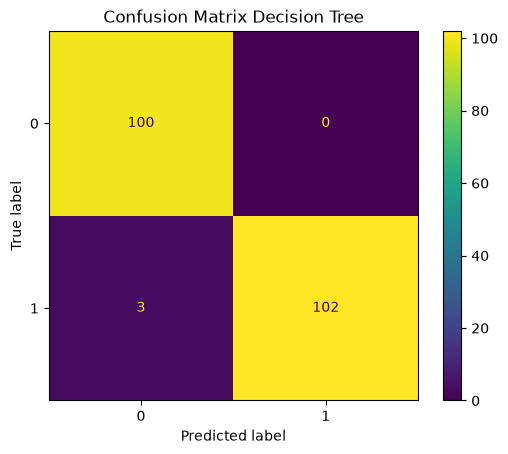

In [63]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt
)

disp.plot()

plt.title("Confusion Matrix Decision Tree")

plt.savefig('images/confusion_matrix_dt.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Insight

Confusion Matrix menunjukkan jumlah prediksi yang benar maupun salah pada masing-masing kelas. Nilai Accuracy, Precision, Recall, dan F1-Score akan dibandingkan dengan model Random Forest pada tahap berikutnya.

# Evaluasi Model Random Forest

Model Random Forest dievaluasi menggunakan data testing dengan metrik yang sama agar hasil kedua model dapat dibandingkan secara objektif.

In [49]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf
)

recall_rf = recall_score(
    y_test,
    y_pred_rf
)

f1_rf = f1_score(
    y_test,
    y_pred_rf
)

In [50]:
print("Accuracy :", accuracy_rf)

print("Precision :", precision_rf)

print("Recall :", recall_rf)

print("F1 Score :", f1_rf)

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


### Classification Report Random Forest

In [51]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



### Confusion Matrix Random Forest

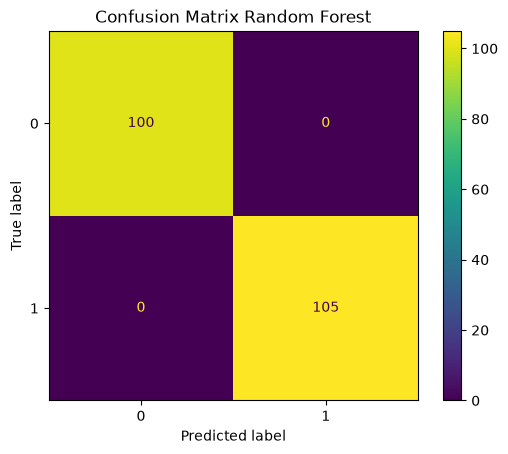

In [64]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf
)

disp.plot()

plt.title("Confusion Matrix Random Forest")

plt.savefig('images/confusion_matrix_rf.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Insight

Hasil evaluasi Random Forest menunjukkan kemampuan model dalam mengklasifikasikan pasien berdasarkan data testing. Nilai evaluasi akan dibandingkan dengan Decision Tree untuk menentukan model terbaik.

# Perbandingan Hasil Evaluasi

Untuk menentukan model terbaik, dilakukan perbandingan berdasarkan nilai Accuracy, Precision, Recall, dan F1-Score.

In [53]:
hasil = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_dt,
        accuracy_rf
    ],

    "Precision":[
        precision_dt,
        precision_rf
    ],

    "Recall":[
        recall_dt,
        recall_rf
    ],

    "F1 Score":[
        f1_dt,
        f1_rf
    ]

})

hasil

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.985366,1.0,0.971429,0.985507
1,Random Forest,1.000000,1.0,1.000000,1.000000


In [54]:
hasil.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,1.000000,1.0,1.000000,1.000000
0,Decision Tree,0.985366,1.0,0.971429,0.985507


# Model Terbaik

Model terbaik dipilih berdasarkan nilai Accuracy tertinggi. Jika terdapat nilai Accuracy yang sama, maka Precision, Recall, dan F1-Score menjadi pertimbangan tambahan.

Model dengan performa terbaik diharapkan mampu memberikan prediksi penyakit jantung secara lebih akurat dan konsisten.

In [55]:
best_model = hasil.loc[
    hasil["Accuracy"].idxmax()
]

best_model

Model        Random Forest
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1 Score               1.0
Name: 1, dtype: object

### Insight

Berdasarkan hasil evaluasi, model dengan nilai Accuracy tertinggi dipilih sebagai model terbaik pada penelitian ini. Selain Accuracy, nilai Precision, Recall, dan F1-Score juga menunjukkan bahwa model tersebut memiliki performa yang lebih baik dalam mengklasifikasikan data pasien penyakit jantung.

# Kesimpulan Evaluation

Berdasarkan hasil evaluasi terhadap kedua algoritma Machine Learning, diperoleh beberapa kesimpulan sebagai berikut:

- Kedua model berhasil melakukan klasifikasi terhadap dataset Heart Disease.
- Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, F1-Score, Classification Report, dan Confusion Matrix.
- Model dengan nilai Accuracy tertinggi dipilih sebagai model terbaik.
- Model terbaik selanjutnya dapat digunakan sebagai dasar dalam pengembangan sistem prediksi penyakit jantung berbasis Machine Learning.